# Análise dos casos de uso

In [17]:
import ast
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as pl

## Pandas Config

In [18]:
pd.set_option('display.max_columns', None)

## Functions

In [48]:
def fillnone(entry, replacement):
    """
    Return `entry` if it is not None. Otherwise, return `replacement`.
    """
    if entry == None:
        return replacement
    else:
        return entry

def extract(usecases, key):
    """
    Given a list of dicts `usecases`, return a list of all properties 
    of the dicts stored under `key`.
    """
    values = [uc[key] for uc in usecases]
    return values

def select(usecases, key, value, exact=True):
    """
    Return a subset of elements in list of dict `usecases` where 
    property stored under `key` has `value`. If `exact` is False,
    select elements whose value (str) has a substring given by
    `value`.
    """
    if exact == True:
        sel = list(filter(lambda uc: uc[key] == value, usecases))
    else:
        sel = list(filter(lambda uc: fillnone(uc[key], '').find(value) != -1, usecases))
    return sel

def parse_json(valor):
    """Normalizes the contents of the datasets column into a list of dicts.
    Accepts: a list/tuple/ndarray of dicts, a single dict, a JSON string, 
    a string in Python literal format, and null/empty values (returns []).
    """
    if isinstance(valor, dict):
        return [valor]
    if isinstance(valor, (list, tuple)):
        return list(valor)
    if hasattr(valor, "tolist"):        
        return valor.tolist()
    if valor is None or pd.isna(valor):
        return []

    # String
    texto = str(valor).strip()
    if texto in ("", "[]", "nan", "None"):
        return []
    try:
        resultado = json.loads(texto)
    except json.JSONDecodeError:
        resultado = ast.literal_eval(texto)

    return [resultado] if isinstance(resultado, dict) else list(resultado)


class translate_dict(dict):
    """
    A dict that returns the key used if no translation was provided for it.
    """
    def __missing__(self,key):
        return key

## Load data

In [4]:
# Lê os dados:
with open('../dados/limpos/usecases_current.json', 'r') as f:
    data = json.load(f)
usecases_raw = data['data']

In [9]:
# Seleciona casos considerados de uso de dados públicos:
usecases = list(filter(lambda uc: (uc['status_published'] == True) or ((fillnone(uc['comment'], '').find('Ocultado porque') == -1) and (fillnone(uc['comment'], '').find('não atendem aos nossos critérios') == -1)) , usecases_raw))


## Analysis

In [85]:
# Converte os casos para dataframe
df = pd.DataFrame(usecases)

In [86]:
# Amostra
df.sample(3)

,hash_id,name,url,url_archive,description,pub_date,authors,authors_id,geo_level,countries,fed_units,municipalities,email,type,topics,tags,url_source,url_image,comment,datasets,record_date,modified_date,status_published,status_review,type_es,topics_es,countries_es
484,3026202343,Requerimentos de aquisição de armas de fogo de...,https://www.areadetrampo.com.br/requerimentos-...,https://archive.ph/ay3fG,O gráfico visa entendermos o números de autori...,01/2025,[Antonio Marques Jares],[None],Países,[Brasil],None,None,None,"[painel, dashboard ou infográfico, estudo inde...",[Defesa e Segurança],[armas],https://,https://raw.githubusercontent.com/cewebbr/cord...,Cadastrado por César Calafrioli.,[{'data_name': 'SINARM - Sistema Nacional de A...,2025-11-29,None,True,False,"[panel de control o infografía, estudio indepe...",[Defensa y Seguridad],[Brasil]
331,209684948,Mapas Auto-organizáveis Multi-camadas Especial...,https://repositorio.ufpe.br/handle/123456789/6...,https://,O crescimento exponencial na quantidade e aces...,02/2024,"[Marcondes Ricarte da Silva Júnior, Universida...","[None, None]",Não se aplica,None,None,None,None,[artigo científico ou publicação acadêmica],"[Ciência, Informação e Comunicação]","[Mapas Auto-organizáveis, Multi-camadas, Relev...",https://,https://raw.githubusercontent.com/cewebbr/cord...,"Cadastrado por Jacqueline (Ceweb.br).\n""Save P...","[{'data_name': 'Iris', 'data_institution': 'R....",2026-01-19,2026-01-19,True,False,[artículo científico o publicación académica],"[Ciencia, Información y Comunicación]",None
42,1230020663,Ausência de políticas públicas contribui para ...,https://projetocolabora.com.br/ods4/ausencia-d...,https://archive.is/rh3UN,Este trabalho consiste em uma investigação em ...,12/2023,"[Colabora, Bibiana Maia da Silva]","[None, None]",Países,[Brasil],None,None,None,[matéria jornalística],[Educação],"[educação, docentes, absenteísmo, psicologico]",https://,https://projetocolabora.com.br/wp-content/uplo...,Catalogado por: Karine Abreu\nRevisado por: Da...,[{'data_name': 'Progressão DOC I (Obtido Via L...,2026-05-28,2026-07-27,True,False,[artículo periodístico],[Educación],[Brasil]


### Distribuição de tipos de casos de reúso

In [87]:
# Verifica existência de casos com "type" em branco
df['type'].isna().any()

False

In [88]:
df_freq_type = df["type"].explode().value_counts(ascending=False).rename_axis("type").reset_index(name="freq_abs")

In [89]:
df_freq_type["freq_perc"] = (freq_type["freq_abs"] / sum(freq_type["freq_abs"]) * 100).round(2)

In [90]:
df_freq_type

,type,freq_abs,freq_perc
0,artigo científico ou publicação acadêmica,286,41.21
1,matéria jornalística,129,18.59
2,"painel, dashboard ou infográfico",93,13.40
3,aplicativo ou plataforma,84,12.10
4,estudo independente,39,5.62
5,conjunto de dados,31,4.47
6,outro,15,2.16
7,inteligência artificial,9,1.30
8,bot,8,1.15


Text(0.5, 0, 'Tipos de casos de reúso (%)')

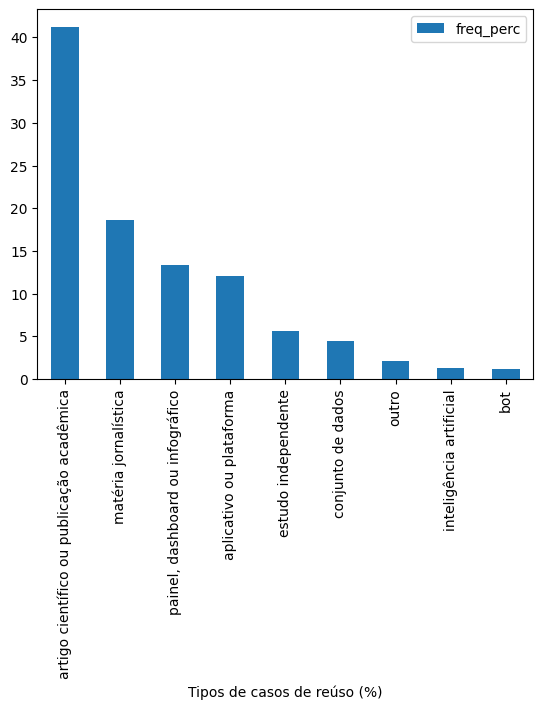

In [91]:
df_freq_type[["type", "freq_perc"]].plot.bar(x="type")
pl.xlabel('Tipos de casos de reúso (%)') # Cada caso pode ter mais de um tipo atrelado

### Distribuição por tipo de licença

In [92]:
# Converte a coluna "datasets" em um dataframe
registros = []
for hash_id, valor in zip(df["hash_id"], df["datasets"]):
    for item in parse_json(valor):
        registros.append({"hash_id": hash_id, **item})

df_datasets = pd.DataFrame(registros)

assert df_datasets["hash_id"].isin(df["hash_id"]).all()

In [93]:
# Verifica existência de casos com "data_license" em branco
df_datasets['data_license'].isna().any()

True

In [94]:
df_datasets.sample(3)

,hash_id,data_name,data_institution,data_url,data_license,data_format,data_periodical
1314,2630772842,Mortalidade Geral 2018,Ministério da Saúde - MS,https://dados.gov.br/dados/conjuntos-dados/sim...,CC-BY,"[CSV, JSON, XML]",False
1027,970699920,Genoma GCA_001570805.1,National Center for Biotechnology Information ...,https://www.ncbi.nlm.nih.gov/datasets/genome/G...,Inexistente,"[ZIP, Outro]",False
855,2934139295,Artigos sobre reabilitação de amputação e enfe...,Scientific Electronic Library Online - SciELO,https://search.scielo.org/advanced/?lang=pt,CC-BY,[Outro],False


In [95]:
df_freq_license = df_datasets["data_license"].value_counts(ascending=False).rename_axis("license").reset_index(name="freq_abs")

In [96]:
df_freq_license["freq_perc"] = (freq_license["freq_abs"] / sum(freq_license["freq_abs"]) * 100).round(2)

In [97]:
df_freq_license

,license,freq_abs,freq_perc
0,Inexistente,913,49.24
1,CC-BY,539,29.07
2,CC BY-ND,103,5.56
3,CC0,76,4.10
4,Outra,68,3.67
5,ODbL,56,3.02
6,CC BY-SA,47,2.54
7,CC BY-NC,18,0.97
8,CC BY-NC-ND,13,0.70
9,GPL,13,0.70


Text(0.5, 0, 'Licenças dos conjuntos de dados (%)')

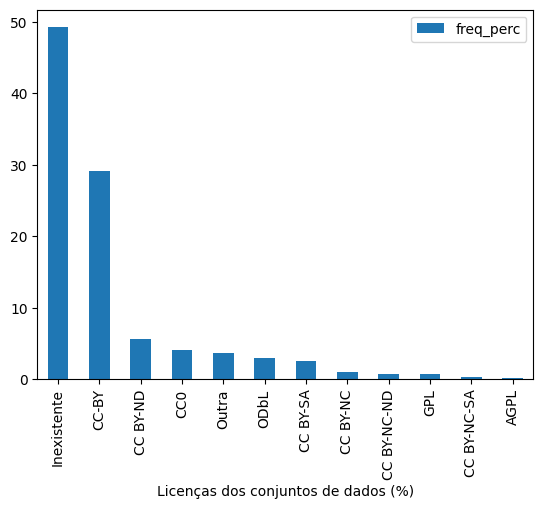

In [104]:
df_freq_license[["license", "freq_perc"]].plot.bar(x="license")
pl.xlabel('Licenças dos conjuntos de dados (%)')

### Casos de reúso de dados abertos x dados públicos

In [73]:
proprietarylicense_list = ["Inexistente"]
openlicense_list = ['CC-BY', 'CC BY-ND', 'CC0', 'Outra', 'ODbL',
       'CC BY-SA', 'CC BY-NC', 'CC BY-NC-ND', 'GPL', 'CC BY-NC-SA',
       'AGPL']

In [74]:
df_datasets["open_license"] = df_datasets["data_license"].isin(openlicense_list)

In [82]:
df_status_license = (
    df_datasets.groupby("hash_id")["open_license"]
    .agg(lambda _: "only_open" if _.all()
                   else ("only_proprietary" if not _.any() else "both"))
    .rename("status_license")
    .reset_index()
)

In [108]:
df_status_license = df_status_license["status_license"].value_counts(ascending=False).rename_axis("status_license").reset_index(name="freq_abs")

In [109]:
df_status_license["freq_perc"] = (df_status_license["freq_abs"] / sum(df_status_license["freq_abs"]) * 100).round(2)

In [111]:
df_status_license

,status_license,freq_abs,freq_perc
0,only_proprietary,231,37.68
1,only_open,226,36.87
2,both,156,25.45


- Tipos de casos de reúso x Uso recorrente dos conjuntos de dados
- Qual é o Nível de cobertura geográfica predominante? Os projetos focam mais em dados de nível nacional, estadual ou municipal?
- Distribuição geográfica por estado (agrupando estados e municípios). Obs: verificar se tem casos do DF, caso Não haja concentrar nesse ponto o que tiver abrangência nacional. Tabular e rankear casos de outros países e fora da Terra.
- Quais são os Temas e Tags mais frequentes? (Ex: Saúde, Educação, Segurança, Política).
- Quantidade de conjuntos de dados por tema
- Quais são as Instituições responsáveis que mais fornecem dados? (Isso revelará se a dependência está concentrada no IBGE, TSE, DATASUS, etc.).
- Qual é o padrão de formatos (Extensão) consumidos? Os usuários estão consumindo formatos abertos (CSV, JSON, API) ou estão tendo que extrair dados de formatos fechados/difíceis (PDF, DOCX)?
- Qual é o nível de transparência metodológica? Quantos casos disponibilizam o Código fonte da análise?
- Detecção de anomalias para verificar a homoneneidade dos casos
- Comparação entre amostras de diferentes universidades e diferentes anos para verificar se podem ser consideradas como obtidas de uma mesma super-população
- Mesma comparação de anos em relação ao prêmio CWA.
